# Generador de trayectorias cartesiano

In [ ]:
# Para correr en Colab
%pip install roboticstoolbox-python
%pip install numpy==1.26.4 --force-reinstall

# Nota importante: da error porque un montón de bibliotecas de Colab dependen de numpy 2, 
# pero como no se utilizan no importa. 
#
# Cuando termina de ejecutarse la celda, pide reiniciar el kernel (aparece un botón bien evidente)
# Luego de reiniciar correr las celdas siguientes

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb
from spatialmath import SE3
from spatialmath import SO3

## Funciones auxiliares de interpolación

In [2]:
def interp_trapezoidal(tseg, thetaA, thetaB, thetaC, T, tacc):
    DA = thetaA - thetaB
    DC = thetaC - thetaB

    if tseg < tacc:  # Zona 1
        theta2p = (DC / T + DA / tacc) / (2 * tacc)
        thetap = (DC / T) * (tseg + tacc) / (2 * tacc) + (DA / tacc) * (tseg - tacc) / (2 * tacc)
        theta = ((DC / T) * (tseg + tacc)**2 / (4 * tacc) +
                 (DA / tacc) * (tseg - tacc)**2 / (4 * tacc) +
                 thetaB)
    else:
        theta2p = np.zeros_like(thetaB)
        thetap = DC / T
        theta = (DC / T) * tseg + thetaB

    return theta, thetap, theta2p

In [3]:
def interp_Sprofile(tseg, thetaA, thetaB, thetaC, T, tacc, orden_interpolacion=4):
    
    VA = (thetaB - thetaA) / tacc
    VD = (thetaC - thetaB) / T

    n = np.arange(orden_interpolacion, -1, -1)

    # Construcción de la matriz M
    M = [(-tacc)**n]
    coef = np.ones_like(n, dtype=float)
    n_min = n.copy()

    for _ in range(orden_interpolacion // 2):
        coef = coef * n_min
        n_min = np.where((n_min - 1) > 0, n_min - 1, 0)
        M.append(coef * (-tacc)**n_min)
        M.append(coef * (tacc)**n_min)

    M = np.vstack(M)

    # RHS
    rhs = np.concatenate([
        np.atleast_1d(thetaA),
        np.atleast_1d(VA),
        np.atleast_1d(VD),
        np.zeros(M.shape[0] - 3)
    ])

    # Coeficientes del polinomio
    p_inter = np.linalg.inv(M) @ rhs

    DA = thetaA - thetaB
    DC = thetaC - thetaB

    if tseg < tacc:  # Zona 1
        theta = p_inter @ (tseg**n)

        exponente_1 = np.where((n - 1) > 0, n - 1, 0)
        thetap = p_inter @ (n * (tseg**exponente_1))

        exponente_2 = np.where((n - 2) > 0, n - 2, 0)
        theta2p = p_inter @ (n * exponente_1 * (tseg**exponente_2))
    else:
        theta2p = np.zeros_like(thetaB)
        thetap = DC / T
        theta = (DC / T) * tseg + thetaB

    return theta, thetap, theta2p

## Interpolación cartesiana

In [99]:
# =========================
# Parámetros
# =========================
orden_interpolador = 2

tm = 1e-3
tacc = 100e-3

Td = [0.5, 0.5, 0.0]

# =========================
# Definición de poses a visitar
# =========================
POSE = [
    SE3.Rz(0) * SE3.Ry(np.deg2rad(45)) * SE3.Trans(-100, -100, 0),
    SE3.Rz(np.deg2rad(10)) * SE3.Rx(np.deg2rad(90)) * SE3.Trans(-100, 100, 0),
    SE3.Rz(np.deg2rad(90)) * SE3.Trans(100, 100, 0),
]

# detenerse en el último punto
POSE.append(POSE[-1])

# =========================
# Inicialización
# =========================
POSE_TRAY = []

idx = 0
POSEA = POSE[0]

# =========================
# Loop principal
# =========================
for i in range(len(POSE) - 1):

    RA = POSEA.R
    Ri = POSE[i].R
    Ri1 = POSE[i+1].R

    th,k_vers = SO3(RA @ Ri.T).angvec()
    THA = np.hstack([
        POSEA.t,
        th*k_vers
    ])

    THB = np.hstack([
        POSE[i].t,
        np.zeros(3)
    ])

    th,k_vers = SO3(Ri1 @ Ri.T).angvec()
    THC = np.hstack([
        POSE[i+1].t,
        th*k_vers
    ])

    T = max(Td[i], 2 * tacc)

    for tseg in np.arange(-tacc + tm, T - tacc, tm):
        idx += 1

        if orden_interpolador == 2:
            TH, THp, TH2p = interp_trapezoidal(tseg, THA, THB, THC, T, tacc)
        else:
            TH, THp, TH2p = interp_Sprofile(tseg, THA, THB, THC, T, tacc, orden_interpolador)

        # reconstrucción orientación
        k_vers = TH[3:6]
        th = np.linalg.norm(k_vers)
        if th>0:
            k_vers = TH[3:6]/th
        R_delta = np.array(SO3.AngleAxis(th,k_vers))
        R = R_delta @ Ri

        POSE_t = SE3.Rt(R, TH[:3])
        POSE_TRAY.append(POSE_t)


    POSEA = POSE_TRAY[-1]

# =========================
# Post-proceso
# =========================
import numpy as np

vecpos = np.array([T.t for T in POSE_TRAY])
vecrot = np.vstack([
    (lambda ang, axis: ang * axis)(*SO3(T.R).angvec())
    for T in POSE_TRAY
])

omega = []
R_ant = POSE_TRAY[0].R
for i in range(len(POSE_TRAY)):
    R_act = POSE_TRAY[i].R
    dR = R_act @ R_ant.T
    th,k_vers = SO3(dR).angvec()    
    omega.append( th*k_vers / tm)
    R_ant = R_act

omega = np.array(omega)
gama = np.diff(omega,axis=0,prepend=0)/tm
vel = np.diff(vecpos,axis=0,prepend=0 ) / tm
acel = np.diff(vel,axis=0,prepend=0 ) / tm

t = np.arange(1, idx+1) * tm

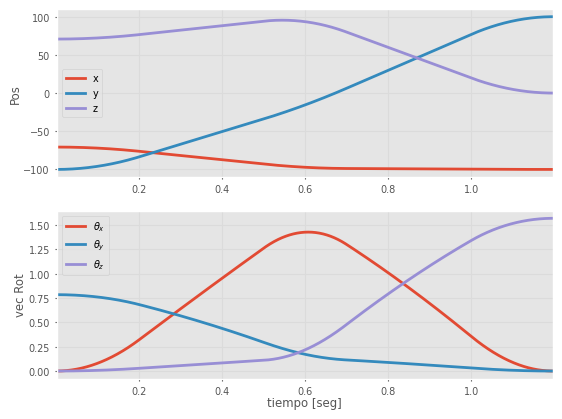

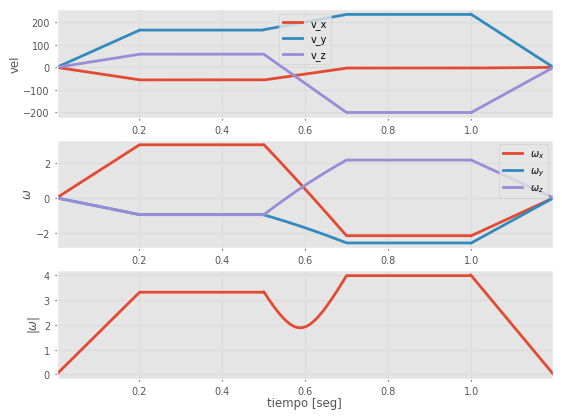

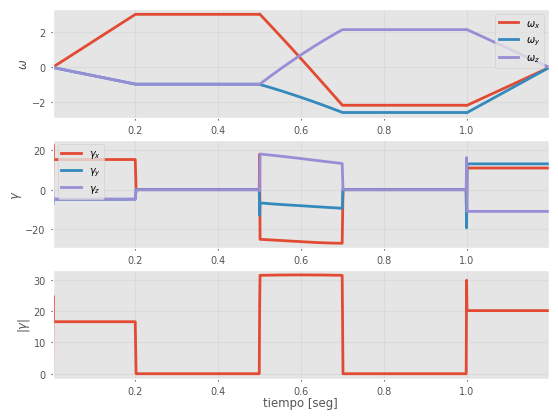

In [100]:
plt.figure(1)
plt.subplot(2,1,1)
plt.plot(t, vecpos, linewidth=2)
plt.ylabel('Pos')
plt.legend(['x','y','z'])
plt.xlim([t[0], t[-1]])

plt.subplot(2,1,2)
plt.plot(t, vecrot, linewidth=2)
plt.ylabel('vec Rot')
plt.legend([r'$\theta_x$', r'$\theta_y$', r'$\theta_z$'])
plt.xlim([t[0], t[-1]])
plt.xlabel('tiempo [seg]')
plt.tight_layout
plt.show()


# --- FIGURA 2 ---
plt.figure(2)
plt.subplot(3,1,1)
plt.plot(t[1:], vel[1:], linewidth=2)
plt.ylabel('vel')
plt.legend(['v_x','v_y','v_z'])
plt.xlim([t[0], t[-1]])

plt.subplot(3,1,2)
plt.plot(t[1:], omega[1:], linewidth=2)
plt.ylabel(r'$\omega$')
plt.legend([r'$\omega_x$', r'$\omega_y$', r'$\omega_z$'])
plt.xlim([t[0], t[-1]])

plt.subplot(3,1,3)
plt.plot(t[1:], np.linalg.norm(omega[1:],axis=1), linewidth=2)
plt.ylabel(r'$|\omega|$')
plt.xlim([t[0], t[-1]])
plt.xlabel('tiempo [seg]')
plt.tight_layout
plt.show()

# --- FIGURA 3 ---
plt.figure(3)
plt.subplot(3,1,1)
plt.plot(t, omega, linewidth=2)
plt.ylabel(r'$\omega$')
plt.legend([r'$\omega_x$', r'$\omega_y$', r'$\omega_z$'])
plt.xlim([t[0], t[-1]])

plt.subplot(3,1,2)
plt.plot(t, gama, linewidth=2)
plt.ylabel(r'$\gamma$')
plt.legend([r'$\gamma_x$', r'$\gamma_y$', r'$\gamma_z$'])
plt.xlim([t[0], t[-1]])

plt.subplot(3,1,3)
plt.plot(t, np.linalg.norm(gama,axis=1), linewidth=2)
plt.ylabel(r'$|\gamma|$')
plt.xlim([t[0], t[-1]])
plt.xlabel('tiempo [seg]')
plt.tight_layout
plt.show()

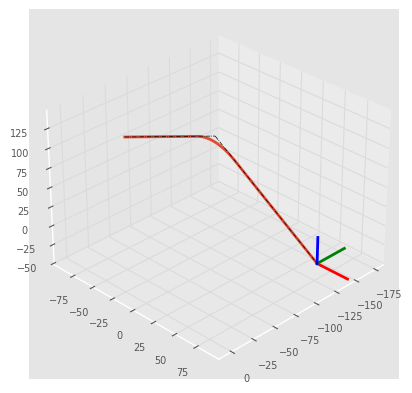

In [107]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


def init_frame_artists(ax, scale=1):
    lines = []
    colors = ['r', 'g', 'b']
    for c in colors:
        line, = ax.plot([0,0], [0,0], [0,0], color=c, linewidth=2)
        lines.append(line)
    return lines

def update_frame_artists(lines, T, scale=0.1):
    origin = T.t
    R = T.R

    for i in range(3):
        axis = R[:, i]
        end = origin + scale * axis

        lines[i].set_data([origin[0], end[0]],
                          [origin[1], end[1]])
        lines[i].set_3d_properties([origin[2], end[2]])

def mostrar_movimiento_3D(POSE, POSE_TRAY, nview=(30,45)):

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.view_init(*nview)

    # límites
    pts_all = np.array([T.t for T in POSE_TRAY])
    span = np.linalg.norm(pts_all.max(axis=0) - pts_all.min(axis=0))
    scale = 0.15 * span   

    ax.set_xlim(pts_all[:,0].min(), pts_all[:,0].max())
    ax.set_ylim(pts_all[:,1].min(), pts_all[:,1].max())
    ax.set_zlim(pts_all[:,2].min(), pts_all[:,2].max())
    def set_axes_equal(ax, pts):
        xmin, ymin, zmin = pts.min(axis=0)
        xmax, ymax, zmax = pts.max(axis=0)

        xmid = 0.5 * (xmin + xmax)
        ymid = 0.5 * (ymin + ymax)
        zmid = 0.5 * (zmin + zmax)

        max_range = max(xmax - xmin, ymax - ymin, zmax - zmin) / 2

        ax.set_xlim(xmid - max_range, xmid + max_range)
        ax.set_ylim(ymid - max_range, ymid + max_range)
        ax.set_zlim(zmid - max_range, zmid + max_range)
    
    set_axes_equal(ax, pts_all)   
    #ax.set_box_aspect([1,1,1])

    # trayectoria
    traj_line, = ax.plot([], [], [], linewidth=2)

    # frame animado (3 ejes)
    frame_lines = init_frame_artists(ax, scale=scale)

    # trayectoria base (opcional, tipo MATLAB)
    for i in range(1, len(POSE)):
        p1 = POSE[i-1].t
        p2 = POSE[i].t
        ax.plot([p1[0], p2[0]],
                [p1[1], p2[1]],
                [p1[2], p2[2]],
                linestyle='-.', color='k')

    jmax = 200

    def update(j):
        i = int(len(POSE_TRAY) * j / jmax)
        i = min(i, len(POSE_TRAY)-1)

        T = POSE_TRAY[i]

        # actualizar frame
        update_frame_artists(frame_lines, T, scale=scale)

        # actualizar trayectoria
        pts = np.array([Tp.t for Tp in POSE_TRAY[:i+1]])
        traj_line.set_data(pts[:,0], pts[:,1])
        traj_line.set_3d_properties(pts[:,2])

        return frame_lines + [traj_line]

    anim = FuncAnimation(fig, update, frames=jmax, interval=20, blit=False)

    return HTML(anim.to_html5_video())

mostrar_movimiento_3D(POSE,POSE_TRAY)